In [1]:
from google.colab import files

uploaded = files.upload()


Saving historical_data.csv to historical_data.csv


In [2]:
from google.colab import files

uploaded = files.upload()


Saving fear_greed_index.csv to fear_greed_index.csv


In [4]:
import pandas as pd

# Load datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

# Shape
print("Trades:", trades.shape)
print("Sentiment:", sentiment.shape)

# Missing values
print(trades.isnull().sum())
print(sentiment.isnull().sum())

# Duplicates
print("Trade Duplicates:", trades.duplicated().sum())
print("Sentiment Duplicates:", sentiment.duplicated().sum())

Trades: (211224, 16)
Sentiment: (2644, 4)
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64
Trade Duplicates: 0
Sentiment Duplicates: 0


In [6]:
# Convert Timestamp IST to datetime
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Convert sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"])

# Create Date column
trades["Date"] = trades["Timestamp IST"].dt.date
sentiment["Date"] = sentiment["date"].dt.date

# Merge
merged_data = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="left"
)

print("Merged Shape:", merged_data.shape)

merged_data[["Timestamp IST", "Date", "classification"]].head()

Merged Shape: (211224, 18)


,Timestamp IST,Date,classification
0,2024-12-02 22:50:00,2024-12-02,Extreme Greed
1,2024-12-02 22:50:00,2024-12-02,Extreme Greed
2,2024-12-02 22:50:00,2024-12-02,Extreme Greed
3,2024-12-02 22:50:00,2024-12-02,Extreme Greed
4,2024-12-02 22:50:00,2024-12-02,Extreme Greed


In [7]:
daily_pnl = merged_data.groupby("Date")["Closed PnL"].sum().reset_index()

daily_pnl.head()


,Date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [8]:
merged_data["Winning Trade"] = merged_data["Closed PnL"] > 0

win_rate = (
    merged_data.groupby("Date")["Winning Trade"]
    .mean()
    .reset_index()
)

win_rate["Winning Trade"] *= 100

win_rate.head()

,Date,Winning Trade
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,36.363636
3,2023-12-15,0.000000
4,2023-12-16,0.000000


In [9]:
avg_trade_size = (
    merged_data.groupby("Date")["Size USD"]
    .mean()
    .reset_index()
)

avg_trade_size.head()

,Date,Size USD
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667


In [10]:
trades_per_day = (
    merged_data.groupby("Date")
    .size()
    .reset_index(name="Trades")
)

trades_per_day.head()

,Date,Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [13]:
# Count Long and Short positions
long_short = merged_data[
    merged_data["Direction"].isin(["Open Long", "Open Short"])
]

long_short_ratio = (
    long_short.groupby(["Date", "Direction"])
    .size()
    .unstack(fill_value=0)
)

# Calculate ratio
long_short_ratio["Long/Short Ratio"] = (
    long_short_ratio["Open Long"] / long_short_ratio["Open Short"]
)

long_short_ratio.head()

Direction,Open Long,Open Short,Long/Short Ratio
Date,,,
2023-05-01,3,0,inf
2023-12-05,7,2,3.5
2023-12-14,3,2,1.5
2023-12-16,3,0,inf
2023-12-17,3,0,inf


In [14]:
print(merged_data.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'classification', 'Winning Trade'],
      dtype='object')


In [15]:
# Average PnL by market sentiment
pnl_by_sentiment = merged_data.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

print(pnl_by_sentiment)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


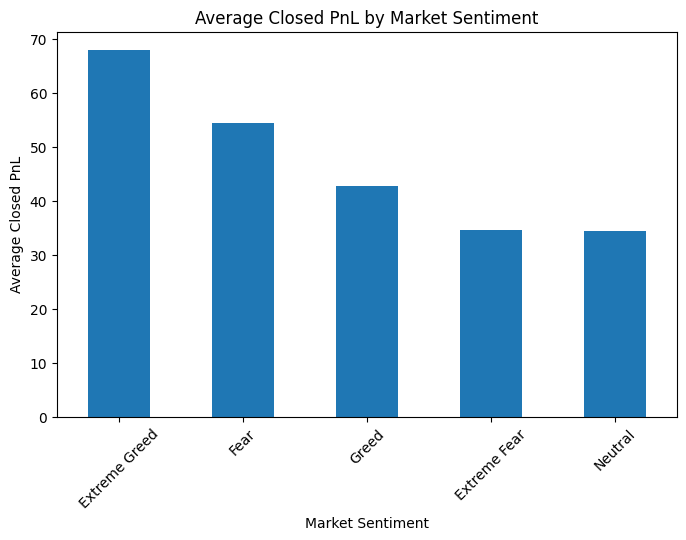

In [16]:
import matplotlib.pyplot as plt

pnl_by_sentiment.plot(kind="bar", figsize=(8,5))

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)

plt.show()

In [18]:
# Win rate by sentiment
win_rate_sentiment = (
    merged_data.groupby("classification")["Winning Trade"]
    .mean() * 100
).sort_values(ascending=False)

print(win_rate_sentiment)

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: Winning Trade, dtype: float64


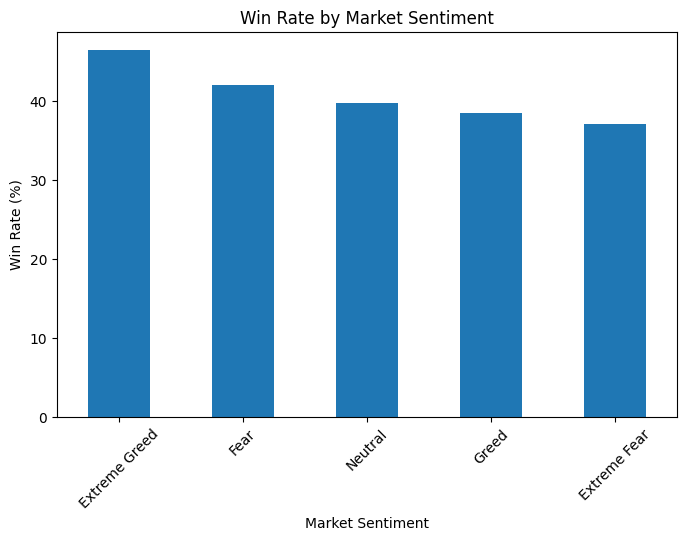

In [19]:
import matplotlib.pyplot as plt

win_rate_sentiment.plot(kind="bar", figsize=(8,5))

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [21]:
# Drawdown proxy: average loss on losing trades
drawdown_proxy = (
    merged_data[merged_data["Closed PnL"] < 0]
    .groupby("classification")["Closed PnL"]
    .mean()
    .sort_values()
)

print(drawdown_proxy)

classification
Extreme Fear    -257.099629
Greed           -181.967329
Fear            -156.662401
Neutral         -121.727849
Extreme Greed   -119.920289
Name: Closed PnL, dtype: float64


In [22]:
# Number of trades by market sentiment
trades_by_sentiment = (
    merged_data.groupby("classification")
    .size()
    .sort_values(ascending=False)
)

print(trades_by_sentiment)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
dtype: int64


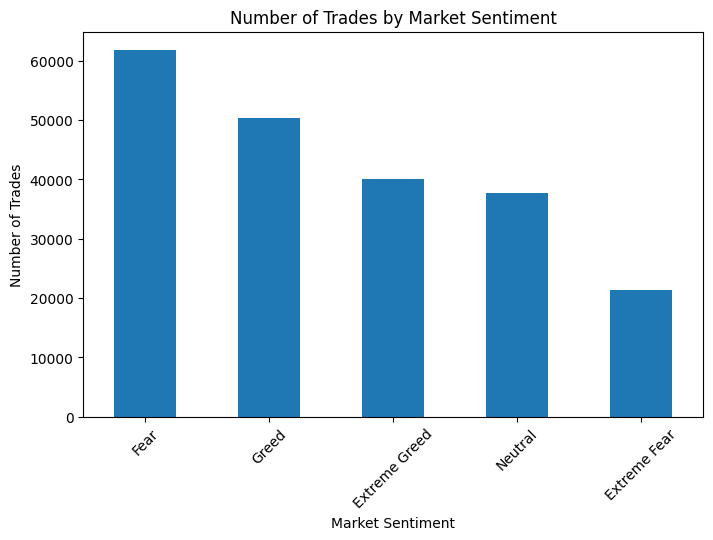

In [23]:
import matplotlib.pyplot as plt

trades_by_sentiment.plot(kind="bar", figsize=(8,5))

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

In [25]:
# Average trade size by market sentiment
avg_trade_size = (
    merged_data.groupby("classification")["Size USD"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_trade_size)


classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


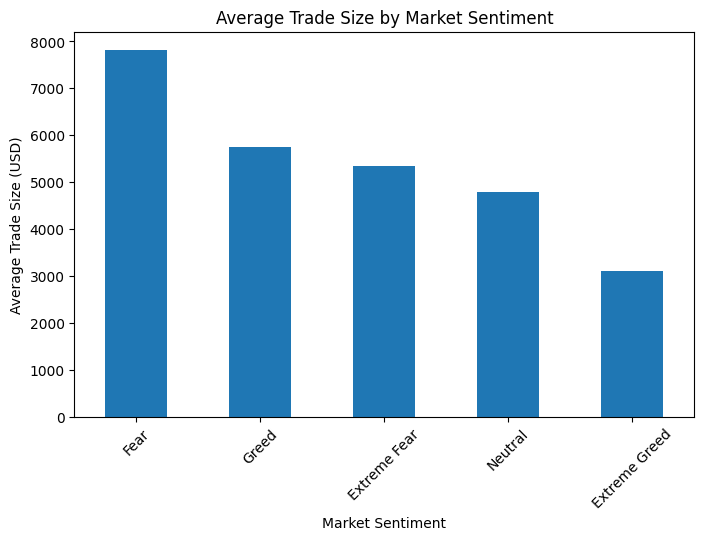

In [26]:
import matplotlib.pyplot as plt

avg_trade_size.plot(kind="bar", figsize=(8,5))

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)

plt.show()

In [28]:
# Count Open Long and Open Short trades by sentiment
long_short_sentiment = merged_data[
    merged_data["Direction"].isin(["Open Long", "Open Short"])
]

long_short_summary = (
    long_short_sentiment.groupby(["classification", "Direction"])
    .size()
    .unstack(fill_value=0)
)

print(long_short_summary)

Direction       Open Long  Open Short
classification                       
Extreme Fear         7005        3174
Extreme Greed        6300        7663
Fear                17824       10887
Greed                8544       11664
Neutral             10222        6353


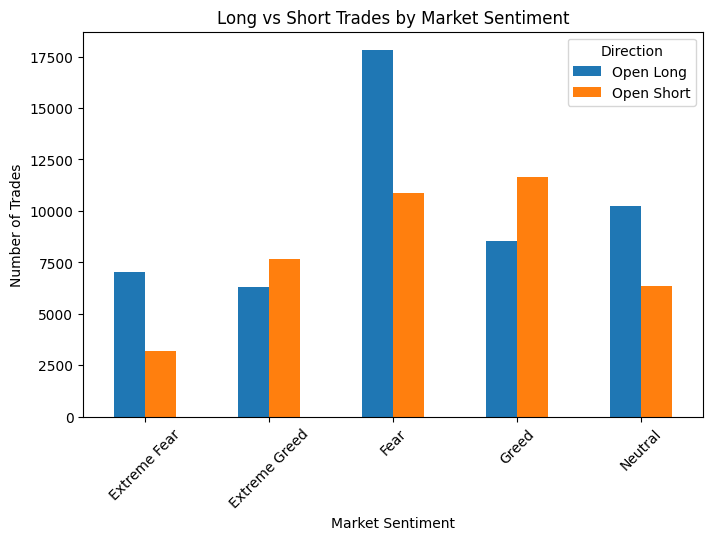

In [29]:
import matplotlib.pyplot as plt

long_short_summary.plot(kind="bar", figsize=(8,5))

plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

In [31]:
# Count trades by account
trade_count = merged_data.groupby("Account").size().reset_index(name="Trade_Count")

# Split traders into two groups using median
median_trades = trade_count["Trade_Count"].median()

trade_count["Trader_Type"] = trade_count["Trade_Count"].apply(
    lambda x: "Frequent Trader" if x > median_trades else "Infrequent Trader"
)

# Merge back with original data
merged_data = merged_data.merge(
    trade_count[["Account", "Trader_Type"]],
    on="Account",
    how="left"
)

# Compare average PnL
segment_pnl = merged_data.groupby("Trader_Type")["Closed PnL"].mean()

print(segment_pnl)

Trader_Type
Frequent Trader      42.493421
Infrequent Trader    96.943024
Name: Closed PnL, dtype: float64


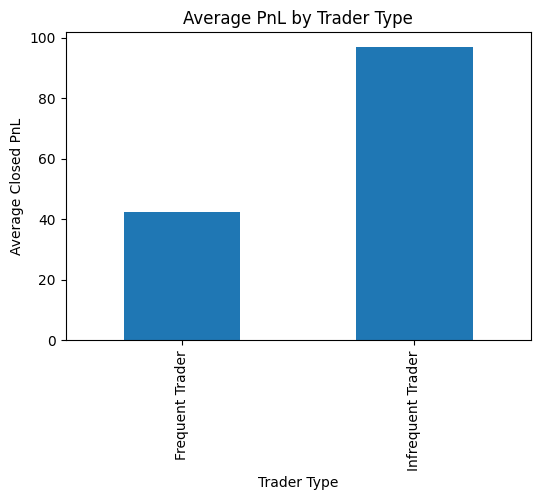

In [32]:
import matplotlib.pyplot as plt

segment_pnl.plot(kind="bar", figsize=(6,4))

plt.title("Average PnL by Trader Type")
plt.xlabel("Trader Type")
plt.ylabel("Average Closed PnL")

plt.show()